Imports:

In [29]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils import get_processed_data_dir

In [30]:
from src.cohort import (
    create_cohort_table,
    create_retention_matrix
)

Load:

In [31]:
import pandas as pd

sales = pd.read_csv(
    get_processed_data_dir()
    / "online_retail_sales.csv",
    parse_dates=["InvoiceDate"]
)

print(sales.shape)
sales.head()

/var/folders/ns/ms3xw2y52nj8x7n_3w_qw4tm0000gn/T/ipykernel_60459/1786661309.py:3: DtypeWarning: Columns (0: Invoice) have mixed types. Specify dtype option on import or set low_memory=False.
  sales = pd.read_csv(


(504731, 16)


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,DescriptionClean,Year,Month,MonthName,Day,DayOfWeek,Hour,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,15CM CHRISTMAS GLASS BALL 20 LIGHTS,2009,12,December,1,Tuesday,7,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,PINK CHERRY LIGHTS,2009,12,December,1,Tuesday,7,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,WHITE CHERRY LIGHTS,2009,12,December,1,Tuesday,7,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,"RECORD FRAME 7"" SINGLE SIZE",2009,12,December,1,Tuesday,7,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,STRAWBERRY CERAMIC TRINKET BOX,2009,12,December,1,Tuesday,7,30.0


Create cohort:

In [32]:
cohort = create_cohort_table(
    sales
)

cohort.head()

,CohortMonth,CohortIndex,Customers
0,2009-12-01,1,955
1,2009-12-01,2,337
2,2009-12-01,3,319
3,2009-12-01,4,406
4,2009-12-01,5,363


Retention:

In [33]:
retention = create_retention_matrix(
    cohort
)

retention

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2009-12-01,100.0,35.287958,33.403141,42.513089,38.010471,35.916230,37.696335,34.240838,33.612565,36.230366,42.198953,49.528796,24.816754
2010-01-01,100.0,20.626632,31.070496,30.548303,26.370757,30.026110,25.848564,22.976501,27.937337,31.853786,30.287206,9.921671,NaN
2010-02-01,100.0,23.796791,22.459893,29.144385,24.598930,20.053476,19.251337,28.609626,25.401070,27.540107,7.219251,NaN,NaN
2010-03-01,100.0,18.961625,23.024831,24.153499,23.250564,20.316027,24.604966,30.248307,27.539503,7.900677,NaN,NaN,NaN
2010-04-01,100.0,19.387755,19.387755,16.326531,18.367347,22.448980,27.551020,26.190476,6.802721,NaN,NaN,NaN,NaN
2010-05-01,100.0,15.748031,16.929134,17.322835,17.716535,25.590551,21.259843,7.874016,NaN,NaN,NaN,NaN,NaN
2010-06-01,100.0,17.407407,18.888889,20.370370,22.962963,28.518519,6.666667,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-01,100.0,15.591398,18.279570,29.569892,29.032258,10.215054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-01,100.0,20.370370,29.629630,32.098765,11.728395,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Heatmap:

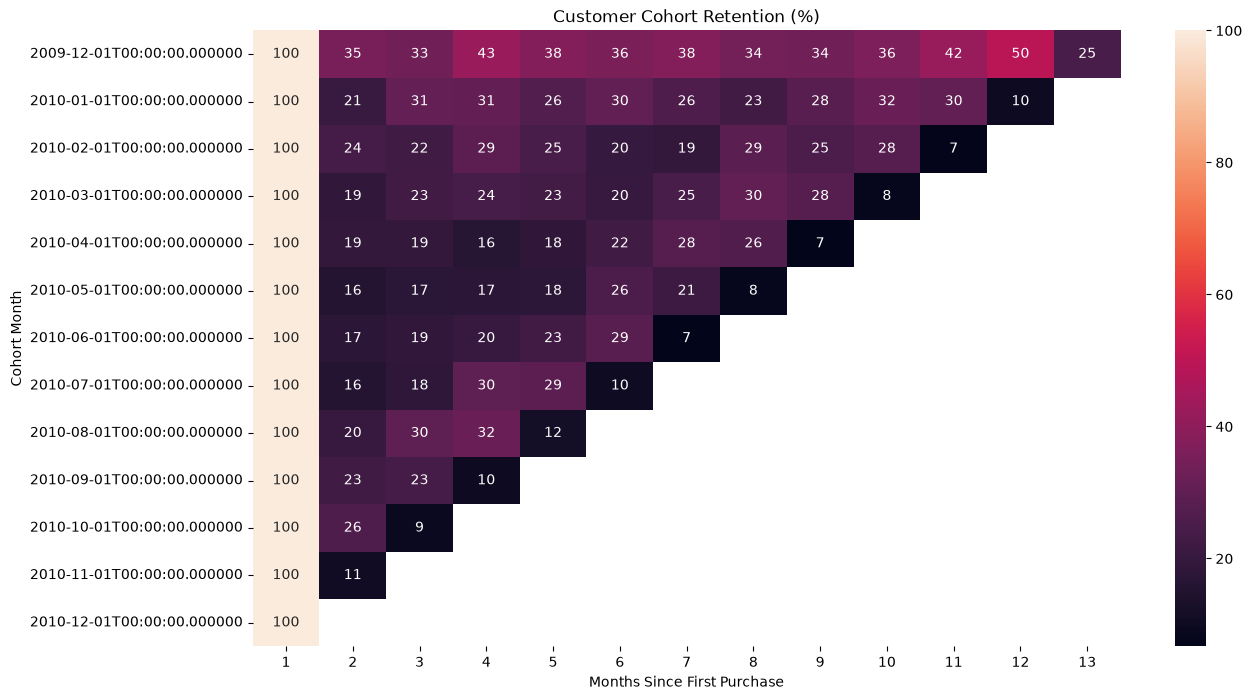

In [34]:
plt.figure(
    figsize=(14, 8)
)

sns.heatmap(
    retention,
    annot=True,
    fmt=".0f"
)

plt.title(
    "Customer Cohort Retention (%)"
)

plt.xlabel(
    "Months Since First Purchase"
)

plt.ylabel(
    "Cohort Month"
)

plt.show()